# idd-figures maps — `map_panel`

A map is painters on a **cartopy GeoAxes cell** inside the GridSpec engine. `map_panel` stacks **title / map / legend / legend-title** as explicit rows (no `tight_layout`); the **map row's height follows the extent's geographic aspect** so the map is undistorted.

Painters: `basemap_painter`, `choropleth_painter` (admin-agnostic fill by a value column), `raster_painter` (pixel maps, binned or continuous), `disputed_boundary_painter`, and the general `bin_legend_panel`. Colours/labels come from `colors.binned_colormap` + `bins.map_bin_labels`. Import-only; made-up values.

## Real global choropleth — Natural Earth Admin 0 (binned)
`make_admin0_polygons()` loads real Natural Earth Admin-0 countries via cartopy (cached on first use) and gives each a made-up value. Discrete bins + rectangle legend.

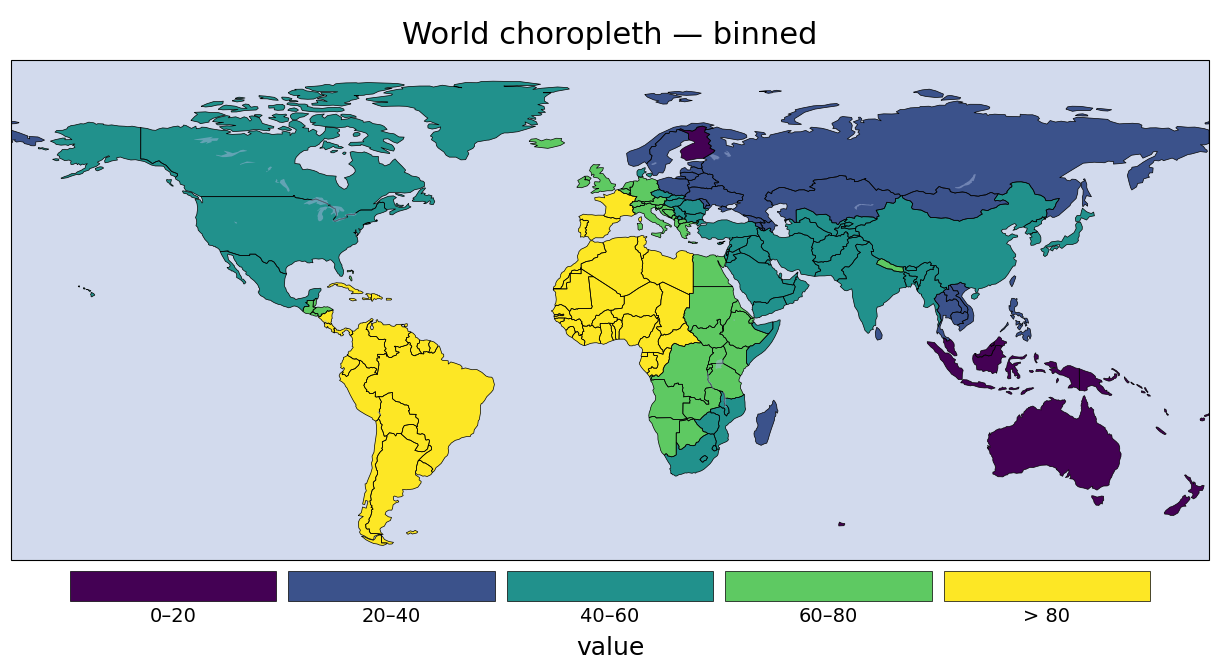

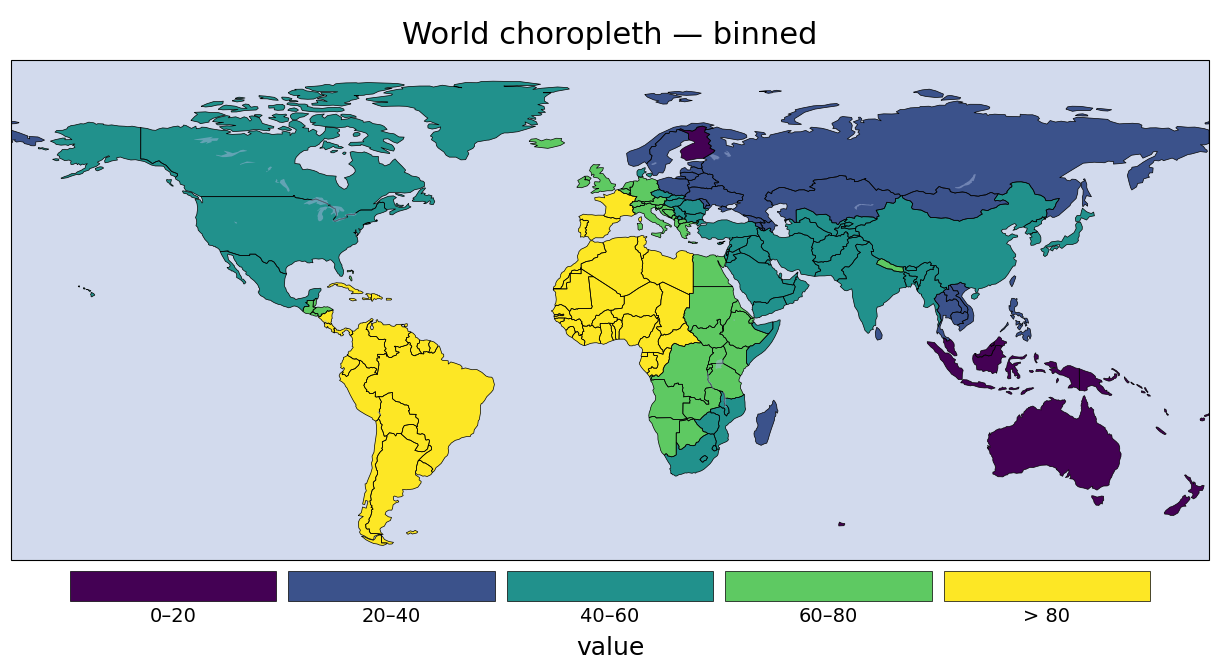

In [1]:
from idd_figures.lib import examples as ex

ex.exemplar_world_choropleth()

## Continuous colour ramp
Same map, but a smooth ramp + a **colorbar** legend instead of discrete bins (`continuous=True`). Continuous vs binned is just which `cmap`/`norm` you pass + `use_colorbar`.

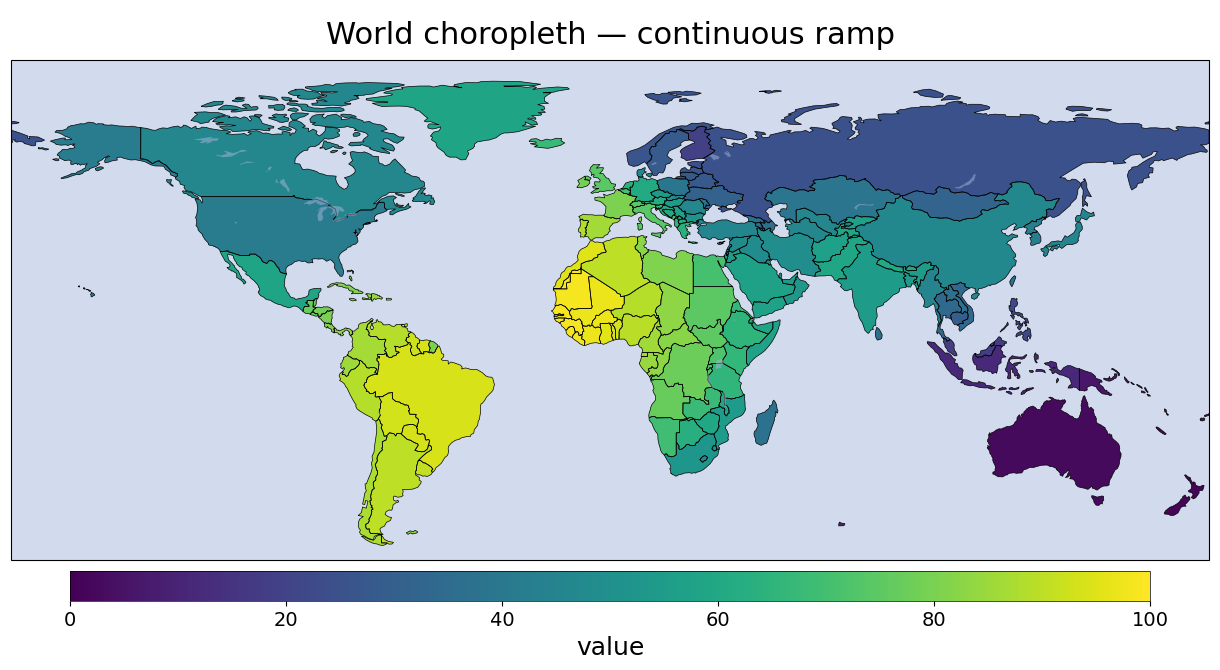

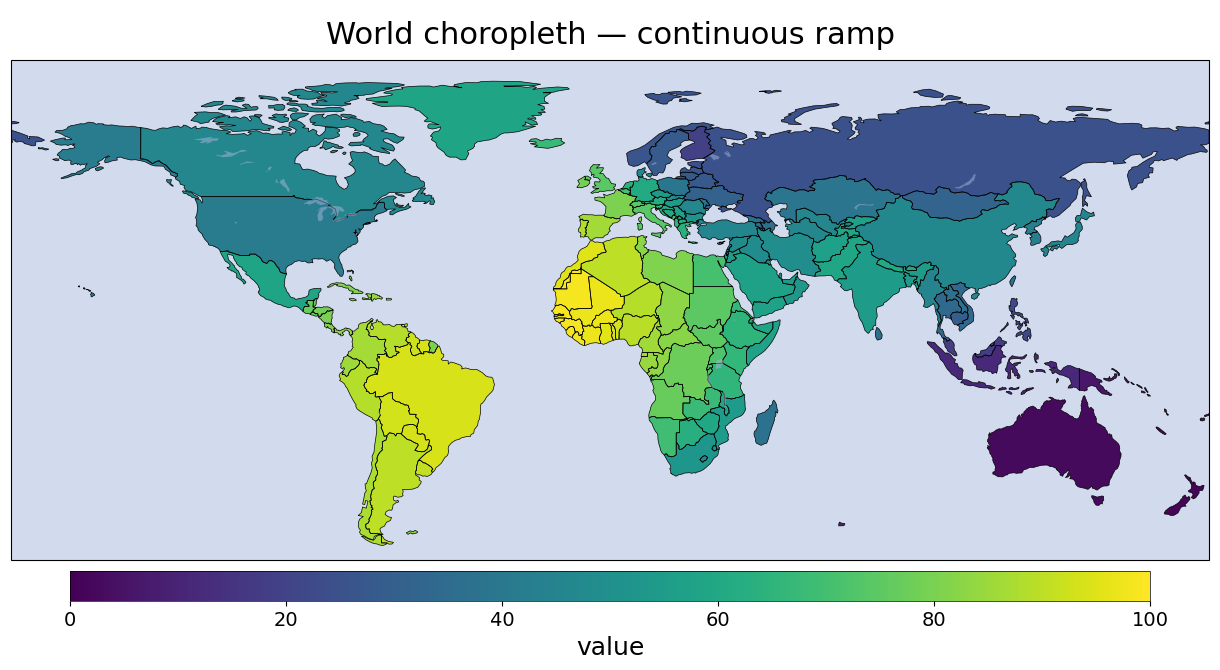

In [2]:
ex.exemplar_world_choropleth(continuous=True)

## Raster / pixel map — binned
`raster_painter` imshows the same field on the GeoAxes — values only over land (masked to Natural Earth countries; **oceans and lakes show through**). Same extent / cmap / bins as the choropleth, so the two look alike — and the choropleth's country values are the **per-country mean of this raster**.

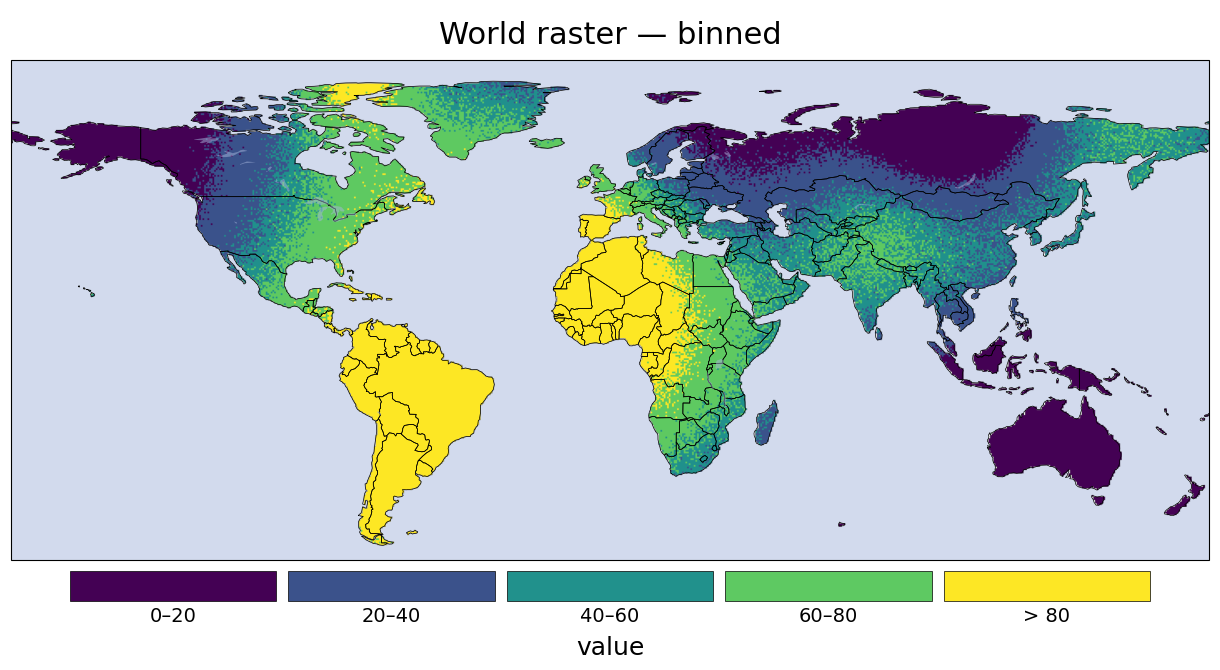

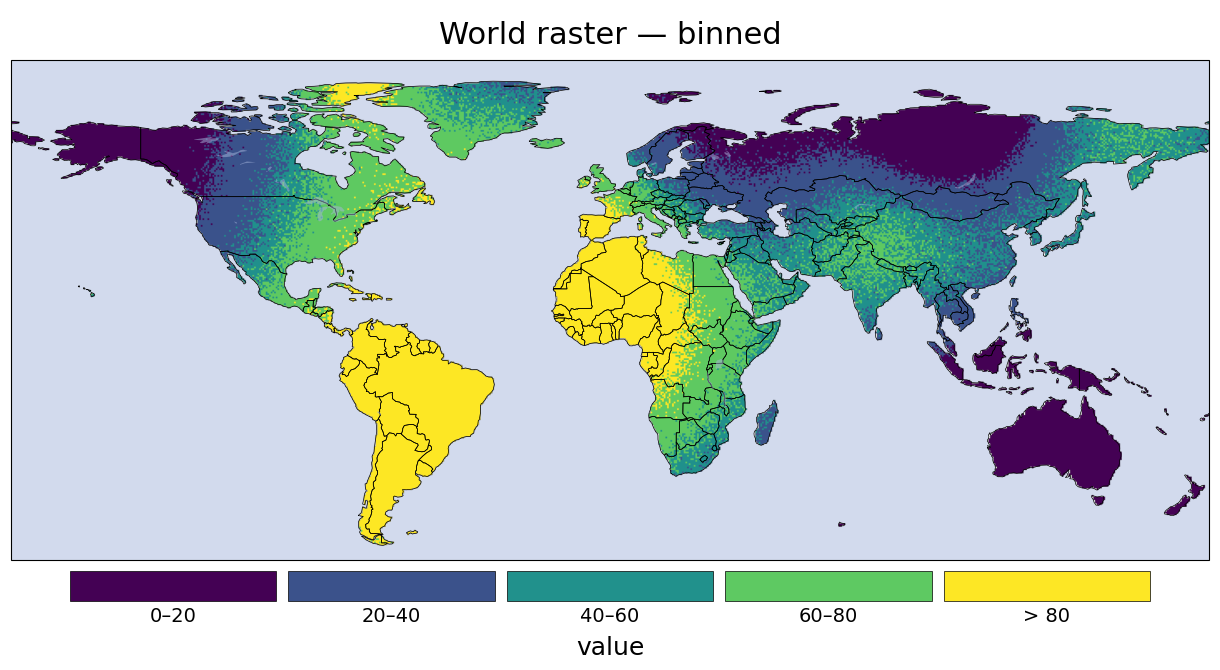

In [3]:
ex.exemplar_pixel_map()

## Raster / pixel map — continuous
Same raster, continuous ramp + colorbar. The four maps (choropleth × raster, binned × continuous) share one extent / cmap / value range → identical layout, near-identical look.

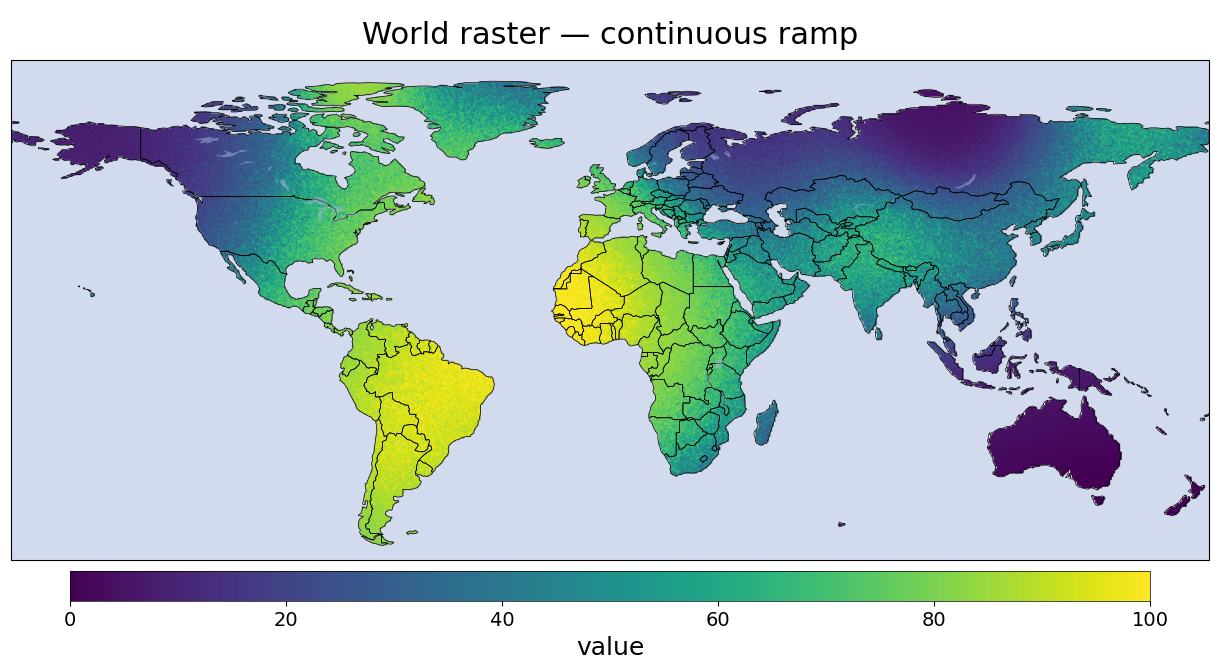

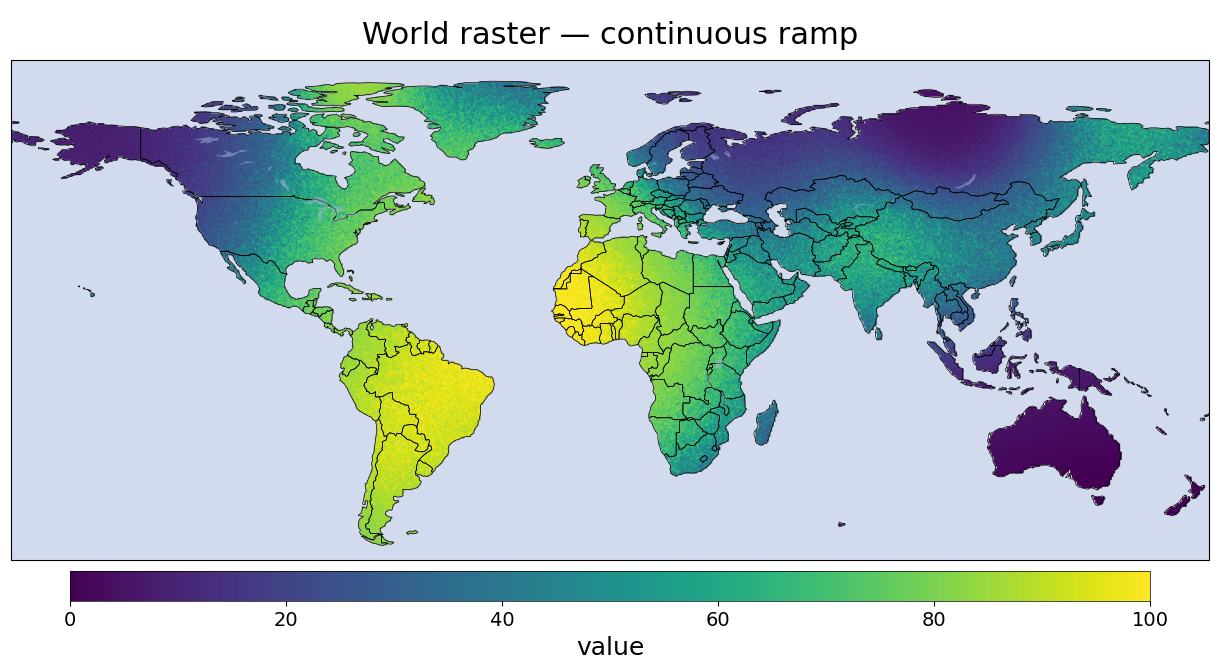

In [4]:
ex.exemplar_pixel_map(continuous=True)

## Aspect-lock, up close
A small offline example (no Natural Earth needed): a 6×4 extent → the map row is `fig_width × 4/6` tall, so squares stay square.

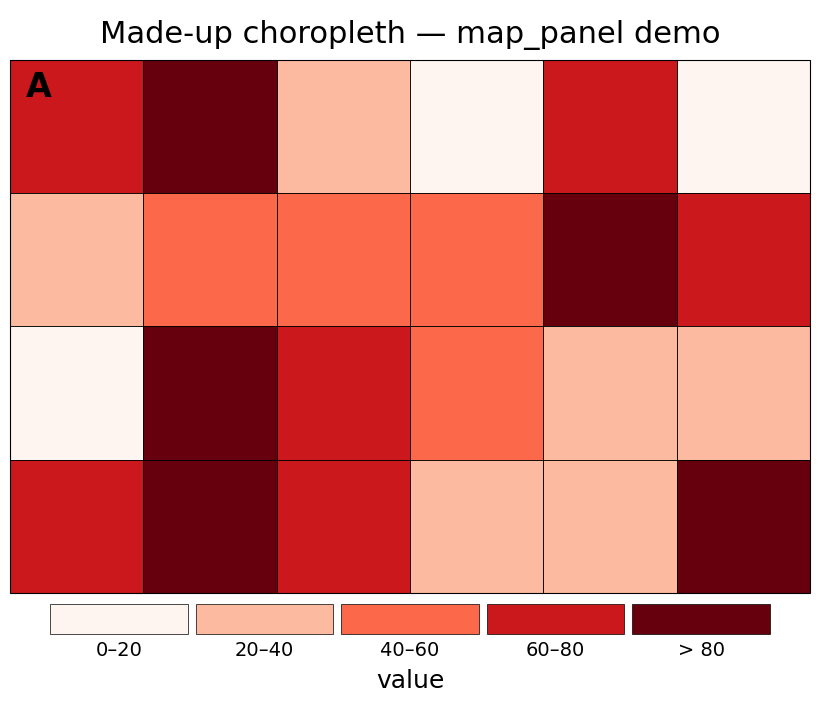

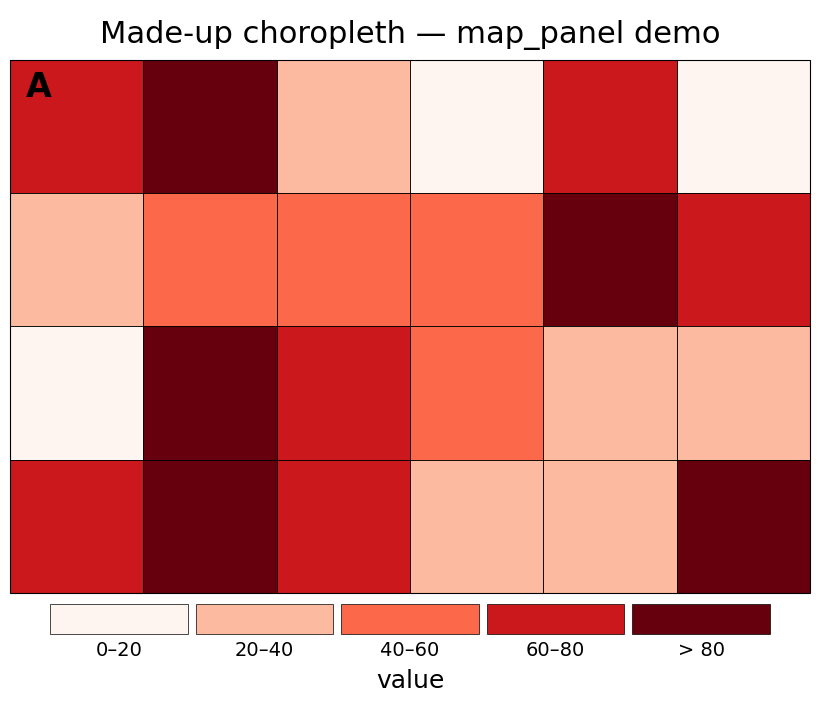

In [5]:
ex.exemplar_map_panel()

## Layout-preview mode
`draw_data=False` renders the full layout (title, legend, frame, basemap) but **skips the expensive map draw** — for fast layout iteration.

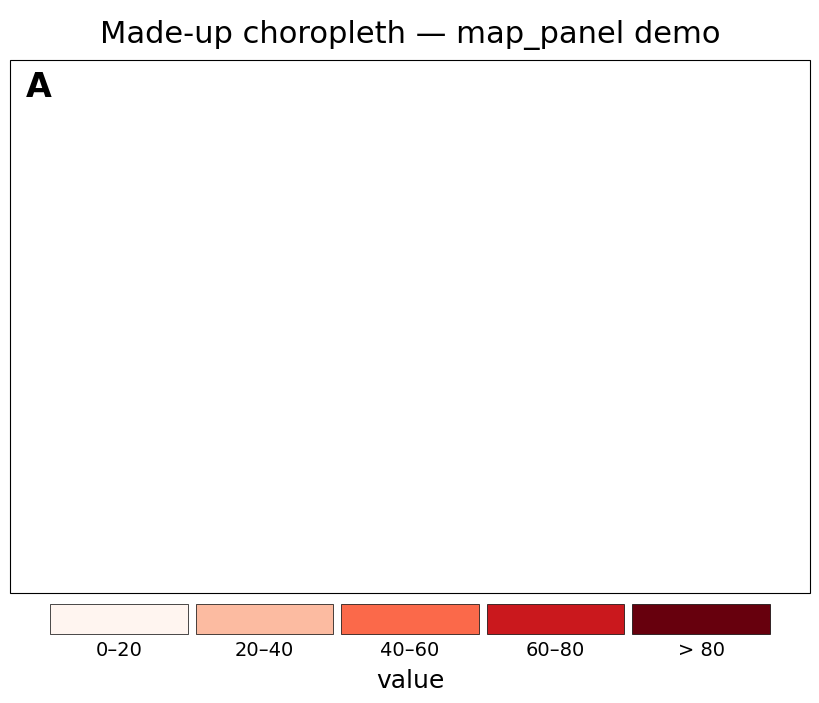

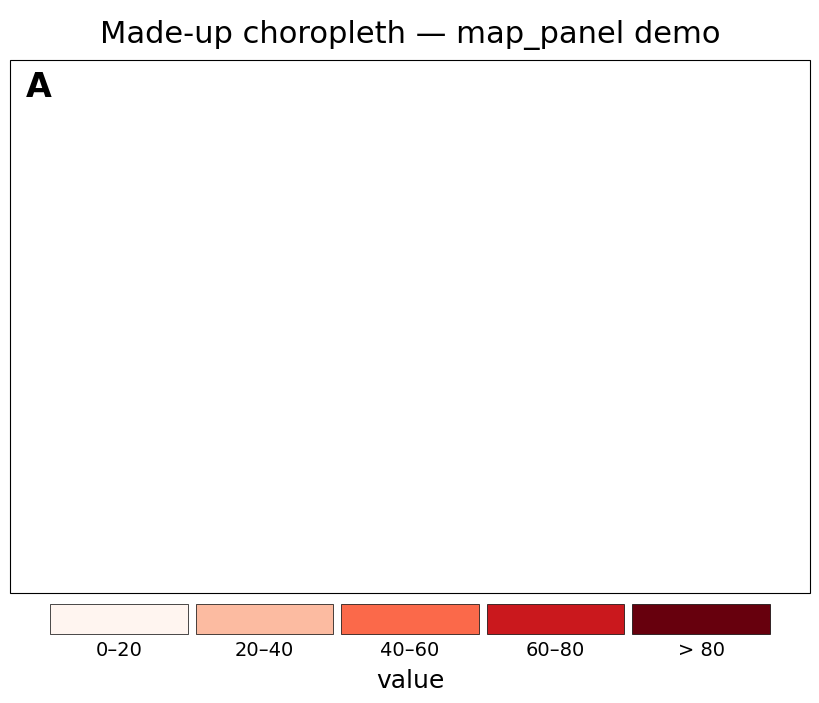

In [6]:
ex.exemplar_map_panel(draw_data=False)

## Full control, with defaults
Every height / font / margin / toggle is a `map_panel` argument (`ocean`, `coastlines`, `borders`, `title_h`, `legend_h`, `legend_title_pos` (`'above'`/`'below'`), `panel_letter`, ...). The caller saves via `idd_figures.lib.io.save_figure` (always `bbox_inches=None`) to an output dir — never the repo.

```python
from idd_figures.lib.example_data import make_admin0_polygons
from idd_figures.lib.colors import binned_colormap
from idd_figures.lib.bins import map_bin_labels
from idd_figures.lib.layouts.maps import map_panel
from idd_figures.lib.io import save_figure

gdf = make_admin0_polygons()                 # or your own admin GeoDataFrame + value col
bins = [0, 20, 40, 60, 80, 100]
cmap, norm, colors = binned_colormap(bins, base_cmap='viridis')
fig = map_panel(gdf=gdf, value_col='value', extent=[-180, 180, -60, 90],
                cmap=cmap, norm=norm, colors=colors, bin_labels=map_bin_labels(bins, ge=True),
                boundary_gdf=gdf, ocean=True, title='...', legend_title='value',
                legend_title_pos='above', panel_letter='A')
save_figure(fig, '/your/output/dir/world_map', formats=['pdf', 'png'])
```